# Minecraft HRL Reasoning Path Benchmark Analysis

Analyzes benchmark results: model performance, context benefit, and error patterns.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Dataset and Results

In [2]:
# Load dataset
with open('reasoning_paths.json') as f:
    dataset = json.load(f)
print(f'Dataset: {len(dataset)} samples')

# Load per-sample metrics (generated by evaluate_results.py)
try:
    with open('benchmark_results/metrics/per_sample_metrics.json') as f:
        per_sample = json.load(f)
    df = pd.DataFrame(per_sample)
    print(f'Results: {len(df)} evaluations')
    print(f'Models: {df["model"].unique()}')
    print(f'Conditions: {df["condition"].unique()}')
except FileNotFoundError:
    print('No benchmark results found. Run benchmark_models.py and evaluate_results.py first.')
    df = pd.DataFrame()

Dataset: 105 samples
Results: 210 evaluations
Models: ['llama3.2:3b']
Conditions: ['with_context' 'without_context']


## 2. Dataset Distribution

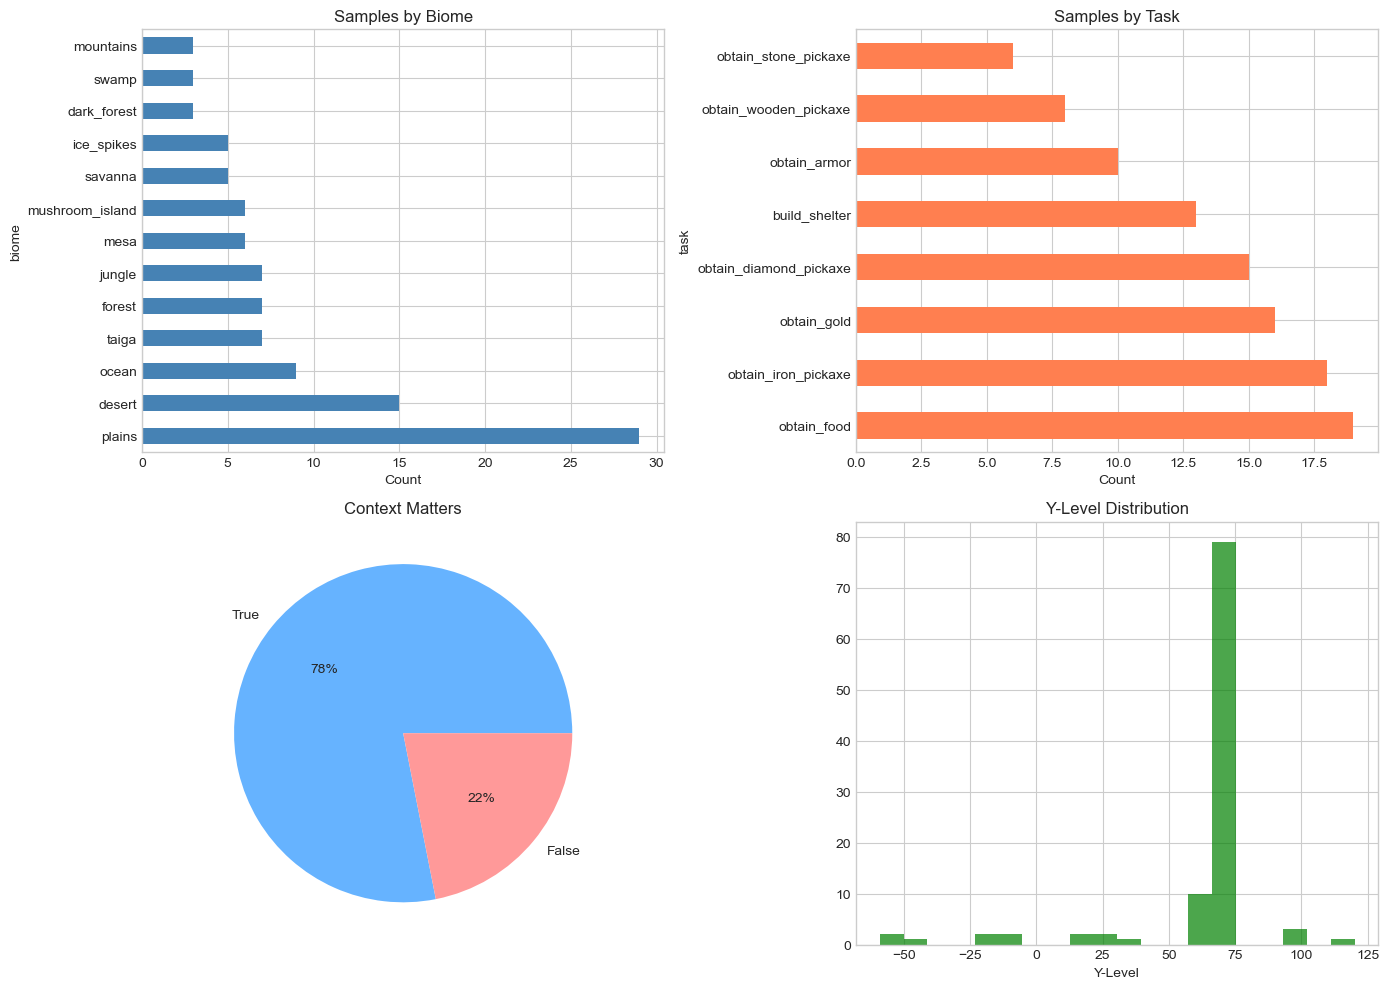

In [3]:
ds = pd.DataFrame(dataset)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Biome distribution
ds['biome'].value_counts().plot.barh(ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Samples by Biome')
axes[0, 0].set_xlabel('Count')

# Task distribution
ds['task'].value_counts().plot.barh(ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Samples by Task')
axes[0, 1].set_xlabel('Count')

# Context matters distribution
ds['context_matters'].value_counts().plot.pie(
    ax=axes[1, 0], autopct='%1.0f%%', colors=['#66b3ff', '#ff9999']
)
axes[1, 0].set_title('Context Matters')
axes[1, 0].set_ylabel('')

# Y-level distribution
ds['y_level'].hist(ax=axes[1, 1], bins=20, color='green', alpha=0.7)
axes[1, 1].set_title('Y-Level Distribution')
axes[1, 1].set_xlabel('Y-Level')

plt.tight_layout()
plt.savefig('benchmark_results/dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Model Performance Comparison

,model,condition,mean_coverage,std_coverage,mean_efficiency,std_efficiency,n
0,llama3.2:3b,with_context,0.165505,0.209872,0.65207,0.248443,105
1,llama3.2:3b,without_context,0.123174,0.167913,0.64799,0.255472,105


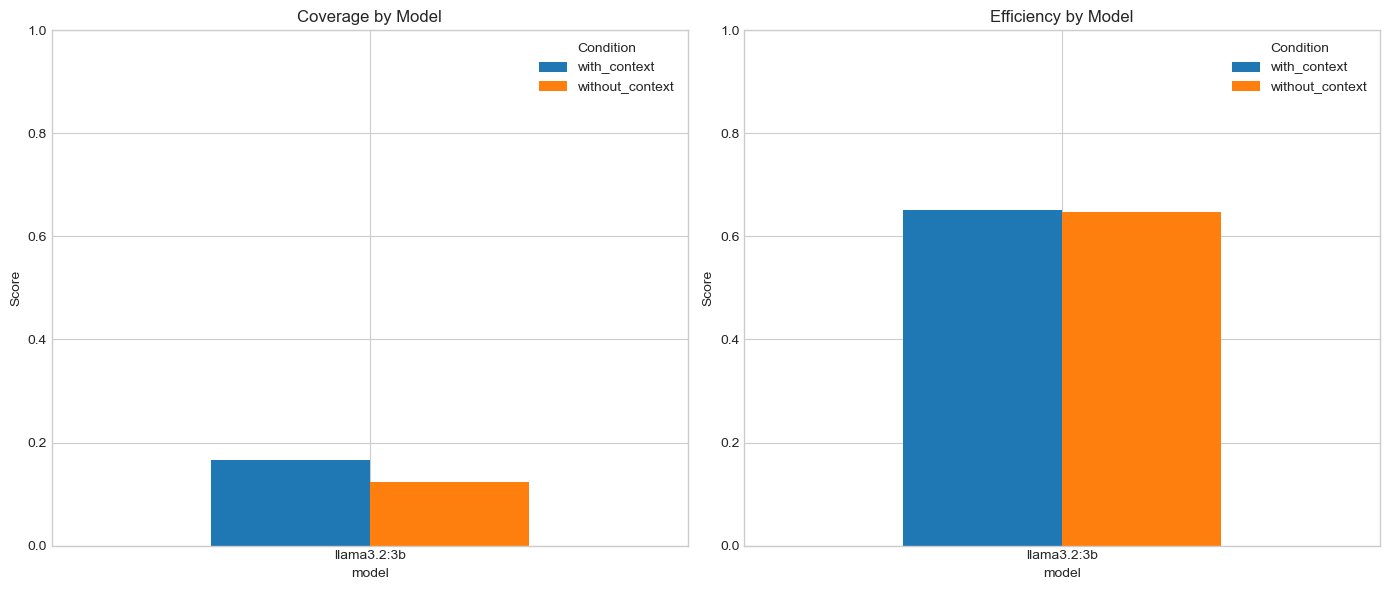

In [4]:
if not df.empty:
    # Aggregate metrics
    agg = df.groupby(['model', 'condition']).agg(
        mean_coverage=('step_coverage', 'mean'),
        std_coverage=('step_coverage', 'std'),
        mean_efficiency=('efficiency_score', 'mean'),
        std_efficiency=('efficiency_score', 'std'),
        n=('step_coverage', 'count'),
    ).reset_index()
    
    display(agg)
    
    # Bar chart: step coverage by model and condition
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for i, metric in enumerate(['mean_coverage', 'mean_efficiency']):
        pivot = agg.pivot(index='model', columns='condition', values=metric)
        pivot.plot.bar(ax=axes[i], rot=0)
        axes[i].set_title(f'{metric.replace("mean_", "").title()} by Model')
        axes[i].set_ylabel('Score')
        axes[i].set_ylim(0, 1)
        axes[i].legend(title='Condition')
    
    plt.tight_layout()
    plt.savefig('benchmark_results/model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No results to plot.')

## 4. Context Benefit Analysis

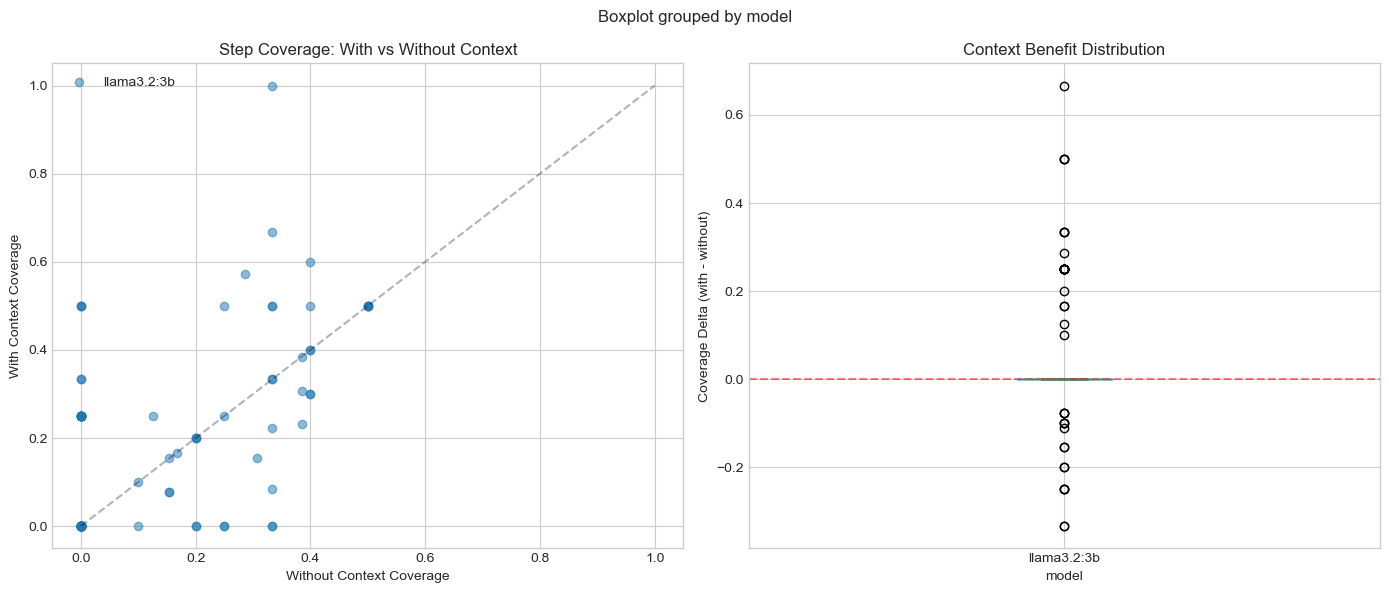

In [5]:
if not df.empty:
    # Paired comparison: with_context vs without_context
    with_ctx = df[df['condition'] == 'with_context'].set_index(['model', 'sample_id'])
    without_ctx = df[df['condition'] == 'without_context'].set_index(['model', 'sample_id'])
    
    common = with_ctx.index.intersection(without_ctx.index)
    if len(common) > 0:
        paired = pd.DataFrame({
            'with_coverage': with_ctx.loc[common, 'step_coverage'].values,
            'without_coverage': without_ctx.loc[common, 'step_coverage'].values,
            'model': [idx[0] for idx in common],
        })
        paired['delta'] = paired['with_coverage'] - paired['without_coverage']
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Scatter: with vs without context coverage
        for model in paired['model'].unique():
            m = paired[paired['model'] == model]
            axes[0].scatter(m['without_coverage'], m['with_coverage'], alpha=0.5, label=model)
        axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
        axes[0].set_xlabel('Without Context Coverage')
        axes[0].set_ylabel('With Context Coverage')
        axes[0].set_title('Step Coverage: With vs Without Context')
        axes[0].legend()
        
        # Box plot: delta by model
        paired.boxplot(column='delta', by='model', ax=axes[1])
        axes[1].set_title('Context Benefit Distribution')
        axes[1].set_ylabel('Coverage Delta (with - without)')
        axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        plt.savefig('benchmark_results/context_benefit.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print('No results to plot.')

## 5. Error Analysis

Worst performing samples (with context):
  Sample 6: obtain_food in plains (coverage=0.00, missed=['search_for_animals', 'kill_animals_for_meat', 'craft_furnace_or_campfire', 'cook_meat'])
  Sample 8: obtain_armor in plains (coverage=0.00, missed=['harvest_wood', 'craft_planks_and_sticks', 'craft_crafting_table', 'craft_wooden_pickaxe', 'mine_stone', 'craft_stone_pickaxe', 'mine_iron_ore', 'craft_furnace', 'smelt_iron', 'craft_iron_armor_set'])
  Sample 9: obtain_food in plains (coverage=0.00, missed=['go_to_village', 'harvest_village_crops'])
  Sample 10: build_shelter in plains (coverage=0.00, missed=['go_to_village', 'use_existing_village_house'])
  Sample 11: obtain_wooden_pickaxe in savanna (coverage=0.00, missed=['go_to_village', 'check_village_chests', 'if_no_tools_then_standard_progression'])
  Sample 22: obtain_gold in mesa (coverage=0.00, missed=['go_to_ruined_portal', 'loot_portal_chest', 'mine_gilded_blackstone_blocks'])
  Sample 24: obtain_gold in desert (coverage=0.00, mi

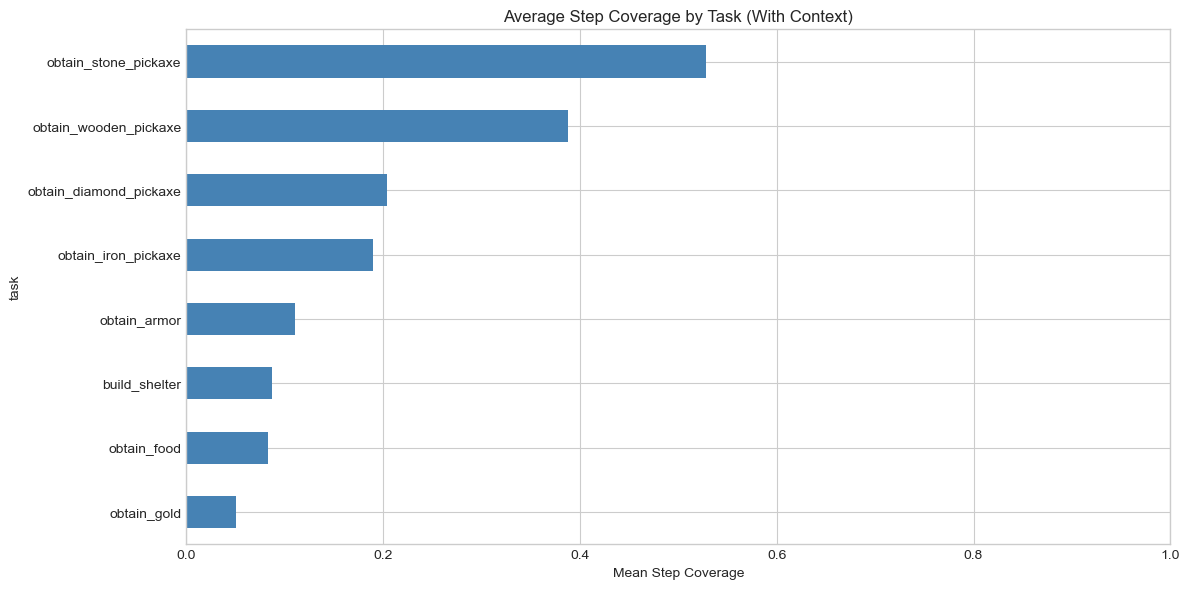

In [6]:
if not df.empty:
    # Find worst-performing samples
    worst = df[df['condition'] == 'with_context'].nsmallest(10, 'step_coverage')
    print('Worst performing samples (with context):')
    for _, row in worst.iterrows():
        sample = next(s for s in dataset if s['id'] == row['sample_id'])
        print(f"  Sample {row['sample_id']}: {sample['task']} in {sample['biome']} "
              f"(coverage={row['step_coverage']:.2f}, "
              f"missed={row.get('missed_steps', 'N/A')})")
    
    # Coverage by task
    task_map = {s['id']: s['task'] for s in dataset}
    df['task'] = df['sample_id'].map(task_map)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    df[df['condition'] == 'with_context'].groupby('task')['step_coverage'].mean().sort_values().plot.barh(
        ax=ax, color='steelblue'
    )
    ax.set_title('Average Step Coverage by Task (With Context)')
    ax.set_xlabel('Mean Step Coverage')
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.savefig('benchmark_results/coverage_by_task.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No results to analyze.')

## 6. Summary Statistics

In [7]:
if not df.empty:
    # Load context benefit CSV
    try:
        cb = pd.read_csv('benchmark_results/metrics/context_benefit.csv')
        print('Context Benefit Summary:')
        display(cb)
    except FileNotFoundError:
        print('No context benefit CSV found.')
    
    # Overall summary
    print(f'\nOverall Summary:')
    print(f'  Total evaluations: {len(df)}')
    print(f'  Models tested: {df["model"].nunique()}')
    print(f'  Mean coverage (with context): {df[df["condition"]=="with_context"]["step_coverage"].mean():.2%}')
    print(f'  Mean coverage (without context): {df[df["condition"]=="without_context"]["step_coverage"].mean():.2%}')
else:
    print('Run benchmark_models.py and evaluate_results.py to generate results.')

Context Benefit Summary:


,model,n_paired_samples,context_benefit_coverage,context_benefit_efficiency,context_benefit_shortcut,p_value_coverage,p_value_efficiency,p_value_shortcut
0,llama3.2:3b,105,0.0423,0.0041,0.94,0.010613,0.778804,0.0



Overall Summary:
  Total evaluations: 210
  Models tested: 1
  Mean coverage (with context): 16.55%
  Mean coverage (without context): 12.32%
